In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Google drive sanga connect gareko -> drive.mount('')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

#Yo chai root directory drive ko
base = '/content/drive/MyDrive'

#Finding the AIF class ko folder
for root, dirs, files in os.walk(base):
  for f in files:
    if f.endswith('.csv'):
      print(os.path.join(root,f))

/content/drive/MyDrive/Classroom/AI Fellowship 2026/clean_patient_data.csv
/content/drive/MyDrive/Classroom/AI Fellowship 2026/WK1/lifestyle_factors.csv
/content/drive/MyDrive/Classroom/AI Fellowship 2026/WK1/patient_demographics.csv
/content/drive/MyDrive/Classroom/AI Fellowship 2026/WK1/clinical_data.csv
/content/drive/MyDrive/Classroom/AI Fellowship 2026/WK1/clean_patient_data.csv


In [4]:
#Classroom ko folder chai yo location ma rahecha so set -> base = location
base = '/content/drive/MyDrive/Classroom/AI Fellowship 2026/WK1/'

# CSV read garera tabular dataframe(dict) ma store garne i.e, demographic,c..,l..
# base + 'filename.ext' -> concatenates the address with filename
demographics = pd.read_csv(base + 'patient_demographics.csv')
clinical = pd.read_csv(base + 'clinical_data.csv')
lifestyle = pd.read_csv(base + 'lifestyle_factors.csv')

#This line only prints on success else the respective error is shown
print("Loaded Successfully.")

# print (values, atributes)
print(f"Demographics : {demographics.shape}")
print(f"Clinical : {clinical.shape}")
print(f"Lifestyle : {lifestyle.shape}")

Loaded Successfully.
Demographics : (8763, 7)
Clinical : (8763, 8)
Lifestyle : (8763, 8)


## Dataset Overview

Three datasets from separate hospital systems for 8763 patients:
- patient_demographics.csv — who the patient is (administrative data)
- clinical_data.csv — lab results (what was measured)
- lifestyle_factors.csv — how the patient lives (survey responses)

Primary Key: `Patient ID` — will be used to merge all three files.

Initial observation: all three files have exactly 8763 rows, meaning every patient has a record in every system. This is unusual in real-world health data likely a controlled data collection at a glance, because quality doesn't mean quality.

Immediate steps taken: Check if all 8763 IDs are actually unique.

In [5]:
# To verify the ID overlap (uniqueness)
# converting the P_ID obtained from accessing the respective dictionary into a
# set so that only unique IDs are recorded
demo_ids = set(demographics['Patient ID'])
clin_ids = set(clinical['Patient ID'])
life_ids = set(lifestyle['Patient ID'])

# Now display the set length for each
print("Unique ID's in demographic : ", len(demo_ids))
print("Unique ID's in clinical : ", len(clin_ids))
print("Unique ID's in lifestyle : ", len(life_ids))

# for now every id is unique in its set
# Check for n(disjoint) in the intersection set
print("\nDemo ∩ Clinical :", len(demo_ids & clin_ids))
print("Clinical ∩ Lifestyle  :", len(clin_ids & life_ids))
print("Lifestyle ∩ Demo  :", len(life_ids & demo_ids))

print("\nDemo - Clinical :", len(demo_ids - clin_ids))
print("Clinical - Lifestyle  :", len(clin_ids - life_ids))
print("Lifestyle - Demo  :", len(life_ids - demo_ids))


Unique ID's in demographic :  8763
Unique ID's in clinical :  8763
Unique ID's in lifestyle :  8763

Demo ∩ Clinical : 8763
Clinical ∩ Lifestyle  : 8763
Lifestyle ∩ Demo  : 8763

Demo - Clinical : 0
Clinical - Lifestyle  : 0
Lifestyle - Demo  : 0


In [6]:
# Check the mismatched ids if they too are unique
# It could be 5 + 5 = 10 or 5 ∩ 5 = 5

demo_not_in_clin = demo_ids - clin_ids
print("In demographics but NOT in clinical : ", demo_not_in_clin)
clin_not_in_life = clin_ids - life_ids
print("In clinical but NOT in lifestyle : ", clin_not_in_life)

#Are they the same patients?
print("\nOverlap between the 2 missing groups : ")
print(demo_not_in_clin & clin_not_in_life)

# Final verdict
# Opening .csv in MS Excel then fit column width caused id errors as below
# demo - clinical  : {'MAR6599', 'JUL2572', 'JAN3249', 'JUN5410', 'MAY4858'}
# clinical - life  : {'May-58',  'Jul-72',  'Mar-99',  'Jan-49',  'Jun-10'}
# This error led me to writing this debug cell

In demographics but NOT in clinical :  set()
In clinical but NOT in lifestyle :  set()

Overlap between the 2 missing groups : 
set()


## ID Validation — Findings

All 8763 Patient IDs are unique within each file and perfectly consistent
across all three datasets. Every intersection = 8763, every difference = 0.

**Note on process:** An earlier version of these files (opened via Google Drive
which had passed through Excel) showed 5 corrupted IDs in lifestyle_factors —
e.g. MAY4858 had become May-58, a classic Excel date auto-format bug. This was
caught by the set difference check. Re-downloading directly from Google Classroom
resolved the issue.

**Key lesson:** Equal row counts do not guarantee matching keys. Always verify
ID overlap explicitly before merging. A silent left-join on mismatched keys
would have dropped those patients without any error or warning.

Safe to proceed with merge.

In [7]:
# === DEMOGRAPHICS ===
print("=" * 50)
print("DEMOGRAPHICS")
print("=" * 50)
print(demographics.head(3))
print()
demographics.info()
print()
print(demographics.describe(include='all').round(2))

# Age Distribution
print("Age Stats : ", demographics['Age'].describe())
print()

# Sex Distribution
print("Sex Distribution : ", demographics['Sex'].value_counts())
print()
print("Sex % : ")
print(demographics['Sex'].value_counts(normalize=True).mul(100).round(2))
print()

# Country Top 10
print("Top 10 Countries : ", demographics['Country'].value_counts().head(10))
print()

# Continent distribution
print("Continent distribution:")
print(demographics['Continent'].value_counts())
print()

# Hemisphere distribution
print("Hemisphere distribution:")
print(demographics['Hemisphere'].value_counts())
print()

# Income distribution
print("Income stats:")
print(demographics['Income'].describe().round(2))

DEMOGRAPHICS
  Patient ID  Age     Sex  Income    Country      Continent  \
0    BMW7812   67    Male  261404  Argentina  South America   
1    CZE1114   21    Male  285768     Canada  North America   
2    BNI9906   21  Female  235282     France         Europe   

            Hemisphere  
0  Southern Hemisphere  
1  Northern Hemisphere  
2  Northern Hemisphere  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Patient ID  8763 non-null   object
 1   Age         8763 non-null   int64 
 2   Sex         8763 non-null   object
 3   Income      8763 non-null   int64 
 4   Country     8763 non-null   object
 5   Continent   8763 non-null   object
 6   Hemisphere  8763 non-null   object
dtypes: int64(2), object(5)
memory usage: 479.4+ KB

       Patient ID      Age   Sex     Income  Country Continent  \
count        8763  8763.00  8763    8763.00     

## Demographics — Inspection Findings

**Shape:** 8763 rows × 7 columns
**Nulls:** None across all columns
**Dtypes:** All appropriate — Age and Income correctly loaded as int64,
categorical fields as object.

**Notable observations:**

- **Sex:** 69.74% Male (6111), 30.26% Female (2652) — imbalanced by ~2.3:1.
  Group-level comparisons by sex should account for this unequal representation.

- **Age:** range 18–90, mean 53.7, median 54 — mean and median nearly equal
  suggesting a fairly symmetric distribution. Consistent with a heart attack
  risk study population skewing toward middle-older age.

- **Geography:** 20 countries across 6 continents. Top country is Germany (477),
  bottom of top-10 is New Zealand (435) — counts are suspiciously uniform,
  further suggesting synthetic data. Asia is the most represented continent (2543),
  Northern Hemisphere dominates (5660 vs 3103).

- **Income:** range 20,062–299,954, mean ~158k, median ~158k — near-identical
  mean and median with wide std (80,575) suggests uniform distribution across
  the range. Likely synthetic — real income data is typically right-skewed.

**Decision:** No cleaning required for demographics. All dtypes correct,
zero nulls, no anomalies. This file will serve as the anchor for the merge.

In [8]:
# === CLINICAL ===
print("=" * 50)
print("CLINICAL")
print("=" * 50)
print(clinical.head(3))
print()
clinical.info()
print()
print(clinical.describe(include='all'))

# Blood Pressure dtype confirmation
print("Blood Pressure dtype:", clinical['Blood Pressure'].dtype)
print("Sample values:", clinical['Blood Pressure'].head(5).tolist())
print()

# Binary columns
print("Diabetes value counts:")
print(clinical['Diabetes'].value_counts())
print()
print("Family History value counts:")
print(clinical['Family History'].value_counts())
print()

# Numeric ranges
for col in ['Cholesterol', 'Heart Rate', 'Triglycerides', 'BMI']:
    print(f"{col}: min={clinical[col].min()}, max={clinical[col].max()}, mean={clinical[col].mean():.2f}")

CLINICAL
  Patient ID  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0    BMW7812          208         158/88          72         0   
1    CZE1114          389         165/93          98         1   
2    BNI9906          324         174/99          72         1   

   Family History  Triglycerides        BMI  
0               0            286  31.251233  
1               1            235  27.194973  
2               0            587  28.176571  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   object 
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   object 
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-

## Clinical — Inspection Findings

**Shape:** 8763 rows × 8 columns
**Nulls:** None across all columns
**Dtypes:** float64(1), int64(5), object(2)

**Key issue — Blood Pressure stored as object (string):**
Format is "158/88" — systolic/diastolic combined in one string field.
Cannot compute mean, run comparisons, or use in models as-is.
Decision: split into two numeric columns — bp_systolic and bp_diastolic.
This increases feature count by 1 but enables all numeric operations.
The original column will be dropped after splitting.

**Binary columns (stored as int64):**
- Diabetes: 65.3% positive (5716/8763) — majority of patients diabetic,
  unusually high for a general population, consistent with synthetic data.
- Family History: 49.3% positive (4320/8763) — near 50/50 split,
  suspiciously balanced for real-world data.

**Numeric ranges — clinical plausibility check:**
- Cholesterol: 120–400 mg/dL ✓ realistic
- Heart Rate: 40–110 bpm ✓ realistic
- Triglycerides: 30–800 mg/dL ✓ wide but clinically possible
- BMI: 18.0–40.0 ✓ realistic (underweight to obese range)

**Decision:** Only required cleaning is Blood Pressure parsing.
All other columns are correctly typed with no nulls and plausible ranges.

In [9]:
# Split "158/88" into two numeric columns
clinical[['bp_systolic','bp_diastolic']] = (
    clinical['Blood Pressure'].str.split('/',expand=True)
    .astype(float)
)
# Verify the split
print("New columns added:")
print(clinical[['Blood Pressure', 'bp_systolic', 'bp_diastolic']].head(5))
print()

# Check ranges make clinical sense
print("bp_systolic  — min:", clinical['bp_systolic'].min(), " max:", clinical['bp_systolic'].max(), " mean:", clinical['bp_systolic'].mean().round(2))
print("bp_diastolic — min:", clinical['bp_diastolic'].min(), " max:", clinical['bp_diastolic'].max(), " mean:", clinical['bp_diastolic'].mean().round(2))
print()

# Check for any suspicious values
suspicious = clinical[
    (clinical['bp_systolic'] < 70) | (clinical['bp_systolic'] > 200) |
    (clinical['bp_diastolic'] < 40) | (clinical['bp_diastolic'] > 130)
]
print("Suspicious BP rows:", len(suspicious))

New columns added:
  Blood Pressure  bp_systolic  bp_diastolic
0         158/88        158.0          88.0
1         165/93        165.0          93.0
2         174/99        174.0          99.0
3        163/100        163.0         100.0
4          91/88         91.0          88.0

bp_systolic  — min: 90.0  max: 180.0  mean: 135.08
bp_diastolic — min: 60.0  max: 110.0  mean: 85.16

Suspicious BP rows: 0


In [10]:
# Drop original 155/88 format blood pressure
clinical.drop(columns=['Blood Pressure'], inplace=True)

# Confirm the changes
print("Clinical columns now : ", clinical.columns.tolist())
print()

print("Shape:", clinical.shape)

Clinical columns now :  ['Patient ID', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Triglycerides', 'BMI', 'bp_systolic', 'bp_diastolic']

Shape: (8763, 9)


## Blood Pressure — Parsing Decision

Blood Pressure was stored as a single string ("158/88").
Split into two numeric columns: bp_systolic and bp_diastolic.

**Why:**
- String dtype blocks all numeric operations — mean, comparison, modeling
- Systolic and diastolic carry different clinical meaning and should be
  treated as separate features
- No data was lost — every row had a valid "X/Y" format

**Post-split validation:**
- bp_systolic:  range 90–180 mmHg, mean 135.08 ✓ clinically normal range
- bp_diastolic: range 60–110 mmHg, mean 85.16 ✓ clinically normal range
- Suspicious rows (outside expected thresholds): 0

Original 'Blood Pressure' column dropped — replaced entirely by the
two numeric columns.

In [11]:
# === LIFESTYLE ===
print("=" * 50)
print("LIFESTYLE")
print("=" * 50)
print(lifestyle.head(3))
print()
lifestyle.info()
print()
print(lifestyle.describe(include='all').round(3))

LIFESTYLE
  Patient ID  Smoking  Obesity  Alcohol Consumption  Exercise Hours Per Week  \
0    BMW7812        1        0                    0                 4.168189   
1    CZE1114        1        1                    1                 1.813242   
2    BNI9906        0        0                    0                 2.078353   

        Diet  Stress Level  Heart Attack Risk  
0    Average             9                  0  
1  Unhealthy             1                  0  
2    Healthy             9                  0  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   object 
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   

In [12]:
# Binary columns
for col in ['Smoking', 'Obesity', 'Alcohol Consumption']:
    count = lifestyle[col].value_counts()
    pct = lifestyle[col].value_counts(normalize=True).mul(100).round(2)
    print(f"{col}:")
    print(f"  0: {count[0]} ({pct[0]}%)  |  1: {count[1]} ({pct[1]}%)")
print()

# Diet distribution
print("Diet distribution:")
print(lifestyle['Diet'].value_counts())
print()
print("Diet %:")
print(lifestyle['Diet'].value_counts(normalize=True).mul(100).round(2))
print()

# Target variable
print("Heart Attack Risk:")
print(lifestyle['Heart Attack Risk'].value_counts())
print()
print("Heart Attack Risk %:")
print(lifestyle['Heart Attack Risk'].value_counts(normalize=True).mul(100).round(2))
print()

# Stress level
print("Stress Level distribution:")
print(lifestyle['Stress Level'].describe())

Smoking:
  0: 904 (10.32%)  |  1: 7859 (89.68%)
Obesity:
  0: 4369 (49.86%)  |  1: 4394 (50.14%)
Alcohol Consumption:
  0: 3522 (40.19%)  |  1: 5241 (59.81%)

Diet distribution:
Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

Diet %:
Diet
Healthy      33.78
Average      33.23
Unhealthy    32.99
Name: proportion, dtype: float64

Heart Attack Risk:
Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

Heart Attack Risk %:
Heart Attack Risk
0    64.18
1    35.82
Name: proportion, dtype: float64

Stress Level distribution:
count    8763.000000
mean        5.469702
std         2.859622
min         1.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Stress Level, dtype: float64


## Lifestyle — Inspection Findings

**Shape:** 8763 rows × 8 columns
**Nulls:** None across all columns
**Dtypes:** float64(1), int64(5), object(2) — all appropriate

**Binary columns (0/1 flags stored as int64):**
- Smoking: 89.68% positive (7859/8763) — extremely high, unrealistic for
  a general population. Strongly suggests synthetic or biased sampling.
- Obesity: 50.14% positive (4394/8763) — near perfect 50/50 split,
  suspiciously balanced for real-world data.
- Alcohol Consumption: 59.81% positive (5241/8763) — plausible but high.

**Diet — 3 categories, near-perfectly balanced:**
- Healthy: 33.78% | Average: 33.23% | Unhealthy: 32.99%
- A ~33/33/33 split across three lifestyle categories is almost impossible
  in real-world survey data. Confirms synthetic origin.

**Exercise Hours Per Week:** range 0.002–19.999, mean 10.0 hrs/week —
continuous float, no anomalies. Mean of exactly 10.0 is suspiciously round,
again consistent with synthetic generation.

**Stress Level:** 1–10 integer scale, mean 5.47, median 5.0 —
symmetric distribution, no anomalies.

**Target Variable — Heart Attack Risk:**
- 0 (No Risk): 64.18% (5624 patients)
- 1 (At Risk):  35.82% (3139 patients)
- Moderate class imbalance (~1.8:1). Not severe but worth noting for
  future modeling — accuracy alone will be a misleading metric.

**Decision:** No cleaning required for lifestyle. All dtypes correct,
zero nulls, no anomalies. Heart Attack Risk confirmed as binary target.
Note: multiple distribution patterns (smoking rate, diet balance, exercise
mean) confirm this is synthetic data — findings should not be generalised
to real patient populations.

In [13]:
# Using Left Join here since sometimes people can be shameful to admit their
# habits, hence leave them incorrect or NULL
# Just looking at a NULL would mean skipping the entire record of
# that person if a join like Inner Join were to be used

merged = demographics.merge(clinical, on='Patient ID', how = 'left')
merged = merged.merge(lifestyle, on = 'Patient ID', how = "left")

#Validation
print("Merged Shape : ", merged.shape)
print()
print("Columns:", merged.columns.tolist())
print()
print("Post-merge Nulls : ", merged.isnull().sum())


Merged Shape :  (8763, 22)

Columns: ['Patient ID', 'Age', 'Sex', 'Income', 'Country', 'Continent', 'Hemisphere', 'Cholesterol', 'Heart Rate', 'Diabetes', 'Family History', 'Triglycerides', 'BMI', 'bp_systolic', 'bp_diastolic', 'Smoking', 'Obesity', 'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet', 'Stress Level', 'Heart Attack Risk']

Post-merge Nulls :  Patient ID                 0
Age                        0
Sex                        0
Income                     0
Country                    0
Continent                  0
Hemisphere                 0
Cholesterol                0
Heart Rate                 0
Diabetes                   0
Family History             0
Triglycerides              0
BMI                        0
bp_systolic                0
bp_diastolic               0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk        

## Merge — Strategy and Validation

**Strategy:** Two-step left join with patient_demographics as anchor.

merged = demographics LEFT JOIN clinical ON Patient ID
merged = merged LEFT JOIN lifestyle ON Patient ID

**Why left join:**
A left join preserves every patient in demographics regardless of whether
their clinical or lifestyle data exists. Using an inner join would silently
drop patients with incomplete records, introducing selection bias —
healthier patients who skip lab tests or lifestyle surveys would be removed,
skewing the dataset toward sicker or more compliant patients.

**Why demographics as anchor:**
Patient identity (who someone is) exists independently of whether their
measurements were recorded. The administrative record is the most reliable
— a patient can exist without a lab result, but not the other way around.

**Post-merge validation:**
- Shape: (8763, 22) ✓ — all 8763 patients retained, all 22 columns present
- Post-merge nulls: 0 across all columns ✓
- No patients lost, no unexpected columns created

**Final merged columns (22):**
Demographics (6): Age, Sex, Income, Country, Continent, Hemisphere
Clinical (8):     Cholesterol, Heart Rate, Diabetes, Family History,
                  Triglycerides, BMI, bp_systolic, bp_diastolic
Lifestyle (7):    Smoking, Obesity, Alcohol Consumption, Exercise Hours
                  Per Week, Diet, Stress Level, Heart Attack Risk
Shared key (1):   Patient ID

In [14]:
merged.to_csv('/content/drive/MyDrive/Classroom/AI Fellowship 2026/clean_patient_data.csv', index=False)
print("Exported successfully.")
print("Location: AI Fellowship 2026/clean_patient_data.csv")

Exported successfully.
Location: AI Fellowship 2026/clean_patient_data.csv


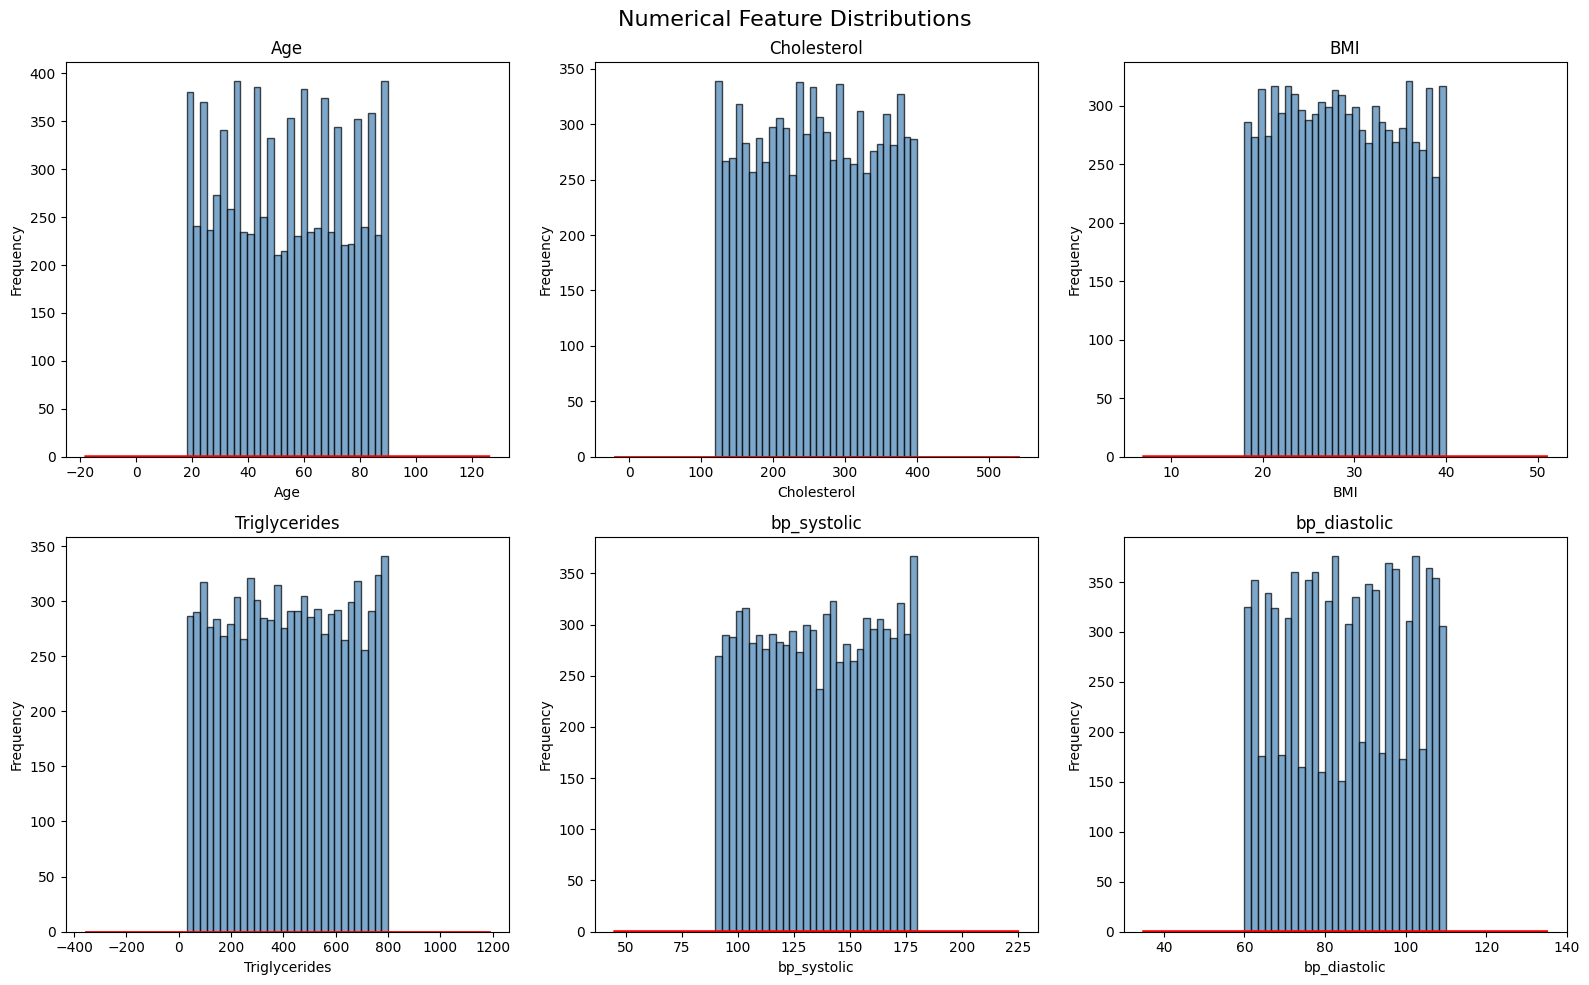

In [15]:
fig, axes = plt.subplots(2, 3, figsize = (16,10))
fig.suptitle('Numerical Feature Distributions', fontsize = 16)

num_cols = ['Age', 'Cholesterol', 'BMI', 'Triglycerides',
            'bp_systolic','bp_diastolic']

for ax, col in zip(axes.flatten(), num_cols):
  merged[col].plot(kind = 'hist', bins = 30, ax = ax, edgecolor = 'black',
                   color = 'steelblue', alpha = 0.7)
  merged[col].plot(kind='kde', ax=ax, secondary_y = False, color='red',
                   linewidth = 2)
  ax.set_title(col)
  ax.set_xlabel(col)
  ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## EDA — Univariate: Numerical Distributions

**Method:** Histogram (30 bins) + KDE overlay for all 6 numeric features.

**Finding: All six features show uniform distributions.**
Bars are roughly equal height across the entire value range for Age,
Cholesterol, BMI, Triglycerides, bp_systolic, and bp_diastolic.
KDE lines are flat — no bell curve, no skew, no natural clustering.

**What this means:**
In real patient data, measurements cluster around biological norms:
- Cholesterol peaks around 180–220 mg/dL
- BMI peaks around 24–27
- Age follows population demographics, not a flat 18–90 spread
Uniform distributions across all six variables simultaneously is
characteristic of synthetic data generated with random uniform sampling.

**Notable observation — bp_diastolic comb pattern:**
Alternating tall/short bars visible in diastolic BP. Likely caused by
rounding bias in value generation (even values more frequent than odd).
Not a data quality issue but worth noting.

**KDE artifact:**
KDE lines extend slightly beyond actual data range (e.g. Age shows
negative values on x-axis). This is expected KDE boundary behaviour —
the kernel smooths past the edge of the data. Not a data problem.

**Decision:** No transformations applied. Uniform distributions require
no log transform or normalization at this stage. Distributions are
noted as synthetic for context in any future modeling.


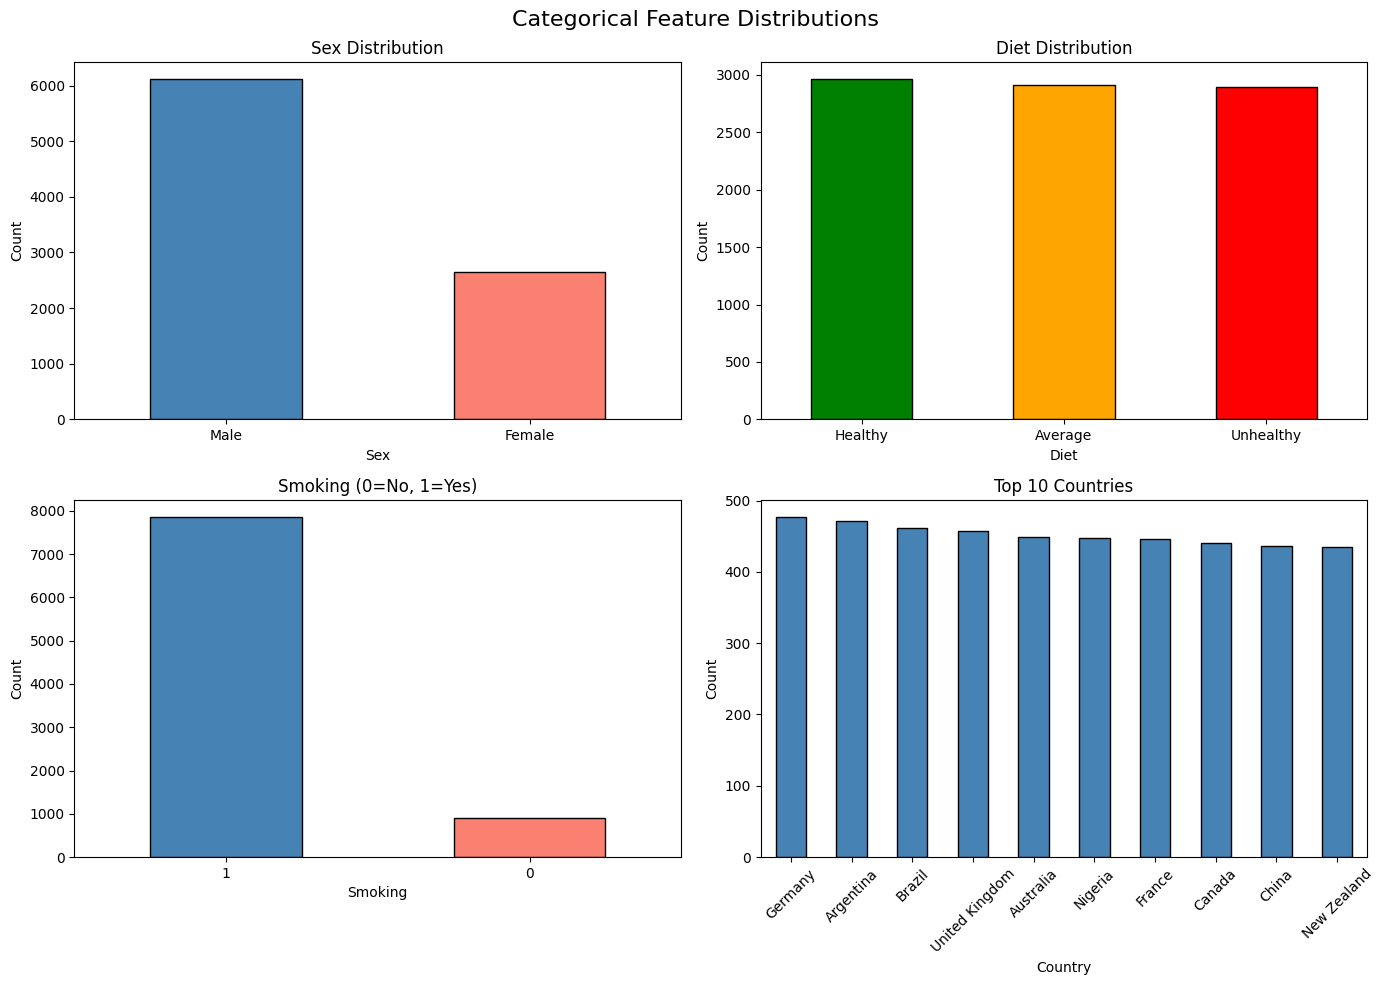

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=16)

# Sex
merged['Sex'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['steelblue','salmon'], edgecolor='black')
axes[0,0].set_title('Sex Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# Diet
merged['Diet'].value_counts().plot(kind='bar', ax=axes[0,1],
    color=['green','orange','red'], edgecolor='black')
axes[0,1].set_title('Diet Distribution')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=0)

# Smoking (binary)
merged['Smoking'].value_counts().plot(kind='bar', ax=axes[1,0],
    color=['steelblue','salmon'], edgecolor='black')
axes[1,0].set_title('Smoking (0=No, 1=Yes)')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)

# Top 10 Countries
merged['Country'].value_counts().head(10).plot(kind='bar', ax=axes[1,1],
    color='steelblue', edgecolor='black')
axes[1,1].set_title('Top 10 Countries')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## EDA — Univariate: Categorical Distributions

**Sex:** Male 69.74% (6111), Female 30.26% (2652) — ~2.3:1 ratio.
Males outnumber females by more than double. Any sex-based analysis
must account for this imbalance.

**Diet:** Near-perfectly equal three-way split —
Healthy 33.78% / Average 33.23% / Unhealthy 32.99%.
A ~33/33/33 distribution is statistically implausible in real survey
data. Confirms synthetic generation.

**Smoking:** 89.68% smokers (1), 10.32% non-smokers (0).
The dominant majority smoke — the opposite of real-world population
rates (~20–25% globally). This extreme imbalance means smoking's
relationship with heart attack risk may not be meaningful here.

**Top 10 Countries:** Germany (477) to New Zealand (435) — a range
of only 42 patients across 10 countries spanning 6 continents.
Gentle decreasing trend but counts are suspiciously uniform.
Real global health data would show orders-of-magnitude differences
between countries based on population size and healthcare access.

**Overall pattern:** All categorical variables reinforce the synthetic
data conclusion. No cleaning required — distributions are as generated.

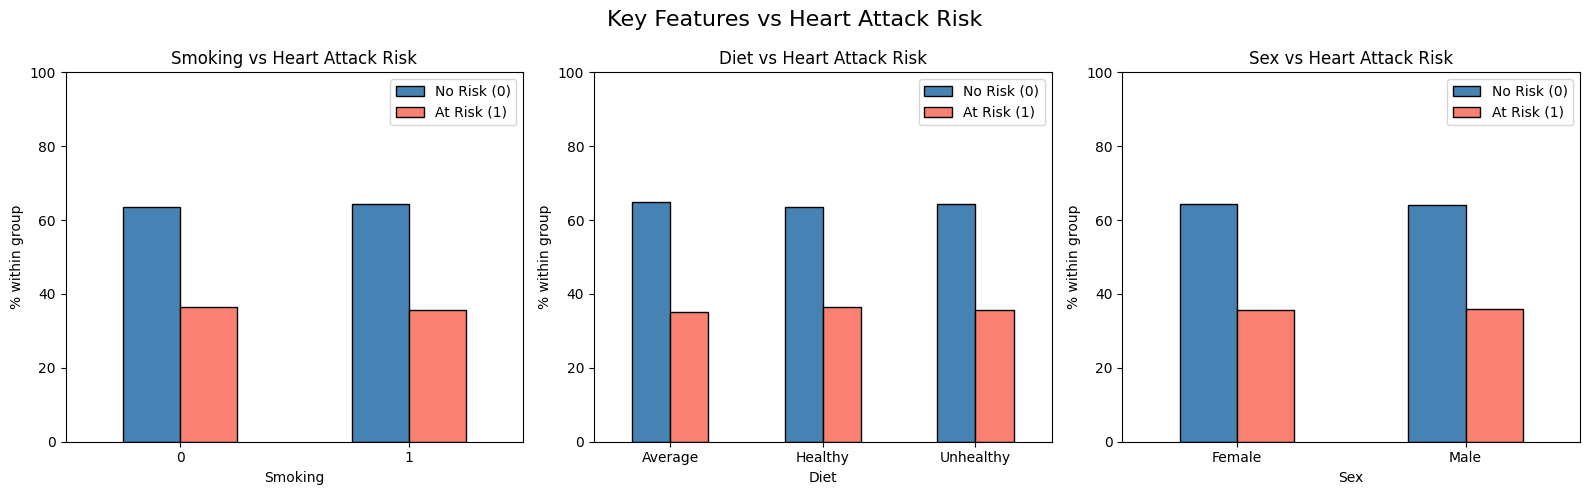

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Key Features vs Heart Attack Risk', fontsize=16)

for ax, col in zip(axes, ['Smoking', 'Diet', 'Sex']):
    ct = pd.crosstab(merged[col], merged['Heart Attack Risk'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, edgecolor='black', color=['steelblue','salmon'])
    ax.set_title(f'{col} vs Heart Attack Risk')
    ax.set_ylabel('% within group')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(['No Risk (0)', 'At Risk (1)'])
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## EDA — Bivariate: Features vs Heart Attack Risk

**Method:** Grouped bar charts using crosstab normalized by row index.
Each bar shows % within that group — making groups comparable despite
unequal sizes.

**Finding: None of the three features separate at-risk from not-at-risk.**

| Feature | No Risk % | At Risk % |
|---|---|---|
| Smoking = 0 (non-smoker) | ~63% | ~37% |
| Smoking = 1 (smoker) | ~65% | ~35% |
| Diet: Average | ~65% | ~35% |
| Diet: Healthy | ~63% | ~37% |
| Diet: Unhealthy | ~64% | ~36% |
| Sex: Female | ~64% | ~36% |
| Sex: Male | ~64% | ~36% |

Every group shows approximately the same 64/36 split as the overall
dataset. Smoking status, diet quality, and sex have no visible
relationship with heart attack risk here.

**Why this matters:**
In real patient data, smoking, diet, and sex are established risk
factors for cardiovascular disease. The absence of any signal here
confirms the target variable (Heart Attack Risk) was assigned
independently of the features during synthetic data generation.
A model trained on this data would learn nothing meaningful from
these variables.

**Implication for modeling:**
Feature selection based on this dataset would be unreliable.
Correlation and importance scores may be near-zero for clinically
significant variables — not because the variables are unimportant,
but because the synthetic generation process removed the real
relationships.

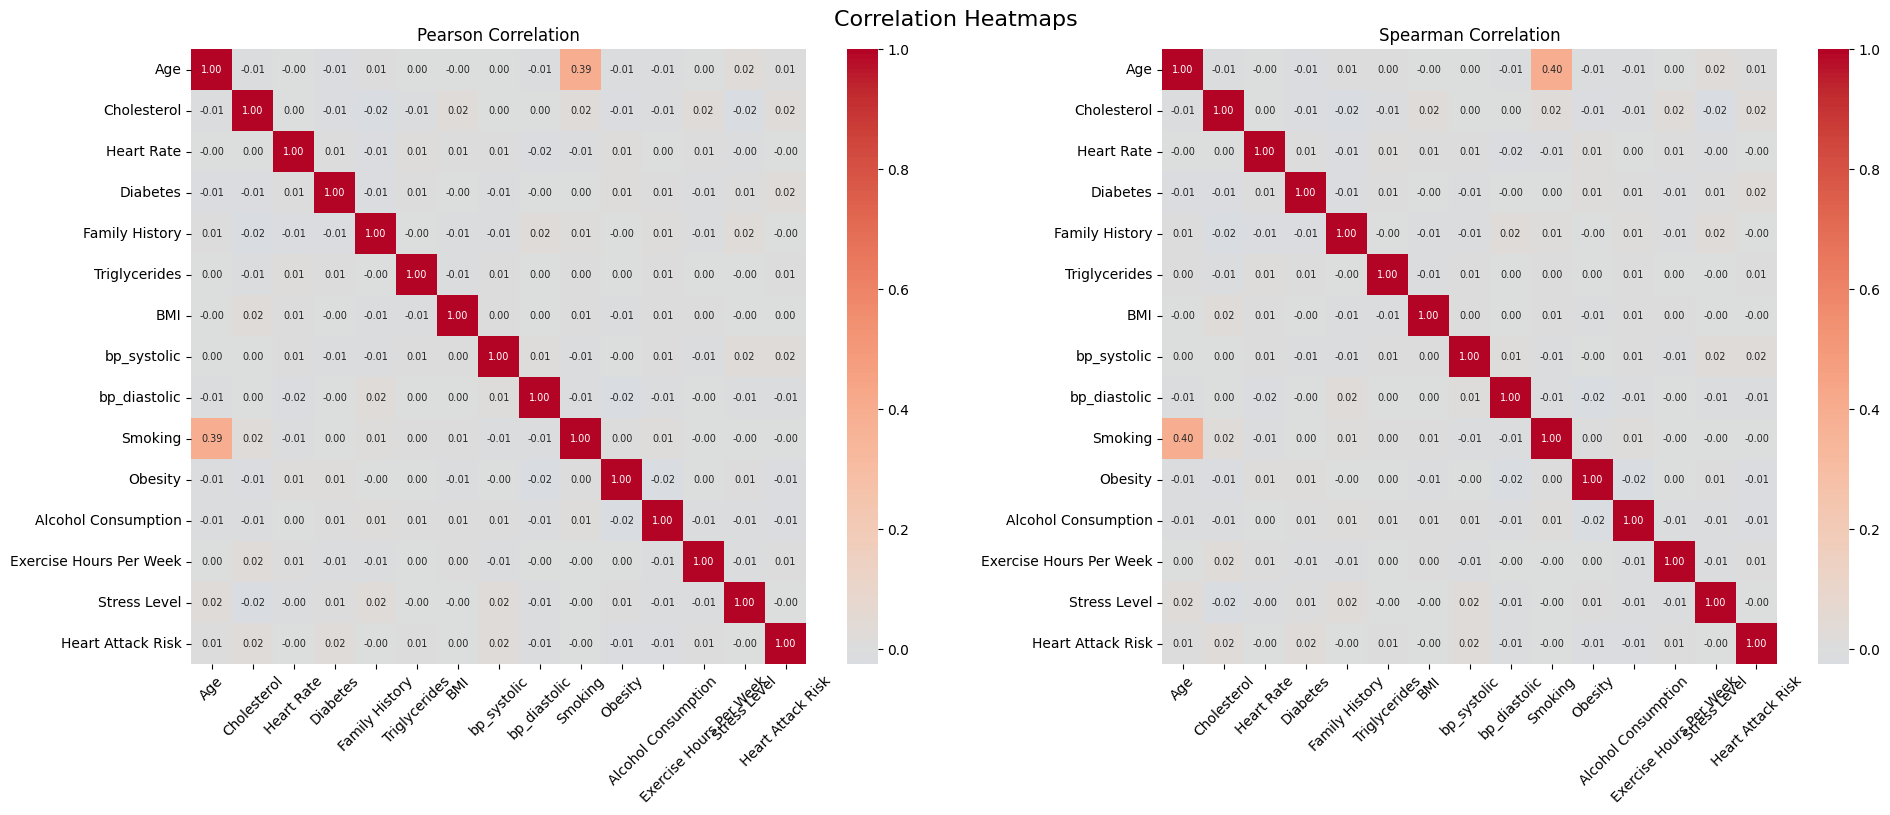

In [18]:
# Select numeric columns only
numeric_cols = ['Age', 'Cholesterol', 'Heart Rate', 'Diabetes',
                'Family History', 'Triglycerides', 'BMI',
                'bp_systolic', 'bp_diastolic', 'Smoking', 'Obesity',
                'Alcohol Consumption', 'Exercise Hours Per Week',
                'Stress Level', 'Heart Attack Risk']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Correlation Heatmaps', fontsize=16)

for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = merged[numeric_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, square=True,
                annot_kws={'size': 7})
    ax.set_title(f'{method.capitalize()} Correlation')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## Correlation Analysis - Pearson & Spearman

**Method:** Side-by-side heatmaps for Pearson (linear) and Spearman (rank-based) correlation across all 15 numeric features.

**Key finding: Near-zero correlation throughout.**
Almost every cell in both heatmaps shows values between -0.02 and 0.02.

**The one exception — Age vs Smoking: 0.39 (Pearson), 0.40 (Spearman).**
This is the only non-trivial correlation in the dataset.
Interpretation: the synthetic data generator likely used age as an input to smoking probability, concentrating non-smokers (10.32% of patients) among younger age groups. This creates an artificial correlation not representative of real-world smoking patterns.This creates an artificial correlation not representative of real-world smoking patterns.

**Heart Attack Risk correlations (last row/column):**
All values are between -0.01 and 0.02 — effectively zero.
No feature has any meaningful linear or rank correlation with the target. This confirms the bivariate finding: Heart Attack Risk was assigned independently of all features during synthetic generation.

**Implication:**
A correlation-based feature selection method (e.g. selecting features with |r| > 0.1) would eliminate every feature from the model. This dataset cannot support meaningful predictive modeling — not because the features are bad, but because the target variable has no real relationship with them.

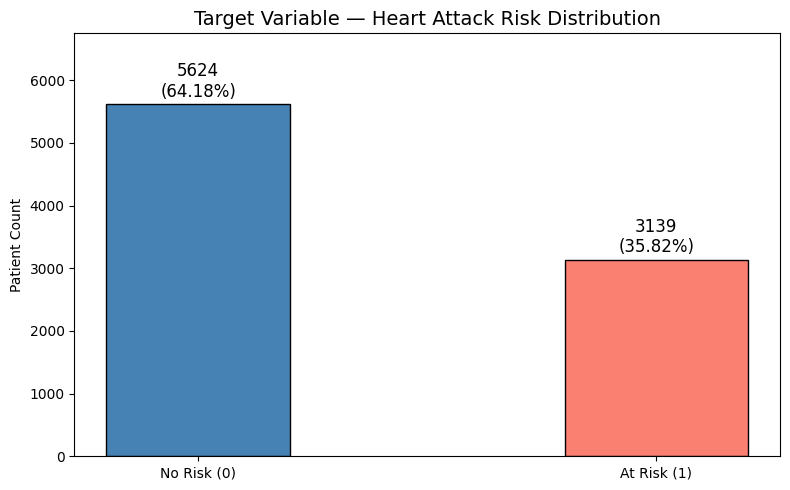

In [19]:
fig, ax = plt.subplots(figsize=(8,5))

counts = merged['Heart Attack Risk'].value_counts().sort_index()
labels = ['No Risk (0)', 'At Risk (1)']
colors = ['steelblue', 'salmon']

bars = ax.bar(labels, counts.values, color = colors, edgecolor = 'black',
              width = 0.4)
# Annotate each bar with count and percentage
total = len(merged)
for bar, count in zip(bars, counts.values):
  pct = count / total * 100
  ax.text(bar.get_x() + bar.get_width() / 2,
          bar.get_height() + 50,
          f'{count}\n({pct:.2f}%)',
          ha='center', va='bottom', fontsize=12)

ax.set_title('Target Variable — Heart Attack Risk Distribution', fontsize=14)
ax.set_ylabel('Patient Count')
ax.set_ylim(0, max(counts.values)*1.2)

plt.tight_layout()
plt.show()

## Target Variable — Heart Attack Risk Distribution

**Distribution:**
- No Risk (0): 5624 patients — 64.18%
- At Risk (1): 3139 patients — 35.82%

**Class imbalance: ~1.79:1 ratio (No Risk : At Risk).**
Not severe, but meaningful. A naive model that predicts "No Risk"
for every patient would achieve 64.18% accuracy without learning
anything. Accuracy alone is therefore a misleading metric for this
dataset — precision, recall, and F1-score are more appropriate
evaluation criteria.

**Why this matters for modeling:**
Techniques like stratified train-test split, class weighting, or
SMOTE oversampling would be worth applying before training any
classifier on this data. Without them, the model will be biased
toward predicting the majority class.

**Note:** Given that all features show near-zero correlation with
this target variable, the imbalance compounds the modeling challenge.
Even a well-tuned model is unlikely to perform above chance on
this synthetic dataset.


## Final Reflection

### Q1. What was the most significant data quality issue you encountered, and how did you resolve it?

The most significant issue was the Excel-induced ID corruption. When one of the
CSV files was opened and resaved in Microsoft Excel, five Patient IDs were silently
reformatted — `MAY4858` became `May-58`, `JUN5410` became `Jun-10`, and so on.
Excel had interpreted them as dates. The values looked plausible at a glance;
there was no error, no warning. A direct merge on those IDs would have produced
NULLs across those 5 rows with no indication of why — the kind of data loss that
is invisible unless you explicitly check ID overlap before joining. The fix was
straightforward: re-download the original CSV directly from Google Classroom and
load it in Colab without opening it anywhere else.

The second notable issue was Blood Pressure stored as a string (`"120/80"`). As a
human you read it as two numbers — but Python sees an `object` dtype, which means
no arithmetic, no comparison, no model input. We split it into `bp_systolic` and
`bp_diastolic` using `/` as a separator, converting both to float, and dropped the
original string column. Net result: +2 columns, -1 column, fully numeric.

Zero nulls across all 23 columns was noted but not treated as an error — it is a
synthetic data characteristic. In a real dataset scaled to a country or continent,
this would warrant serious scrutiny, as genuine surveys always carry missing
responses.

---



### Q2. What did your EDA reveal about the dataset, and what does it tell you about its limitations for real-world use?

The dominant pattern across every variable was unusually uniform distribution.
Category splits landed at almost exact fractions — diet at ~33/33/33 across three
categories. Numerical distributions showed mean ≈ median across age, income, and
exercise hours, which is statistically rare in real health data. Correlations
between all features and the target were at or below |r| = 0.02 — effectively
zero. The only non-trivial correlation in the entire dataset was Age vs Smoking
(r ≈ 0.39), which itself reveals how the data was likely generated: not as one
coherent population system, but attribute by attribute with independent sub-prompts
— something like "higher age → higher probability of smoking." The diet split was
just 1/3 for 3 categories. Heart Attack Risk was most probably synthesized so that
roughly half the population is at risk, without specifying what kind of population
— which causes any slice of the data to carry that same ~50% risk rate regardless
of any other attribute.

This has direct implications for real-world use. A smoking rate of 89.68% against
a global average of ~20–25% is not a data quality error — it is a generation
artifact. Because Heart Attack Risk has near-zero correlation with every other
feature, a model trained here will not learn meaningful clinical relationships —
it will just predict the marginal distribution of the target and get the same value
every time. Findings from this dataset cannot be generalised to real patient
populations. It is suitable for practising data wrangling and pipeline construction,
but not for drawing any clinical conclusions.

---


### Q3. Why did you choose a left join over an inner join, and what are the trade-offs?

In any real-world multi-system dataset, there is a near-certainty that at least
one record will be missing from at least one source. An inner join handles this by
dropping the entire row — not just the missing attribute, but every piece of
information about that patient. A left join retains the row and marks the missing
attributes as NULL, which is visible and handleable. Skipping a person's data
entirely is more costly in real life than the cost of storing and handling NULLs.

Demographics was chosen as the anchor table because of how patient data works in
the real world. We classify data of a person, not a person of the data. In real
life, patient records are unique individual records — organised around name, age,
ID — and clinical or lifestyle attributes are appended to that identity, not the
other way around.

That said, inner join is not always wrong. When calculating statistics of a
demography for clinical health and lifestyle analysis, missing a few values is
of lesser loss than including NULLs and dealing with extra errors in calculation
later. The opposite case would be the same records kept in a hospital — missing
an entire record of a person is far more trouble than a few NULL attributes. The
right join type depends on what missing data costs you in your specific context.

---

### Q4. What would you do differently if this were real patient data instead of synthetic?

The inspection code I wrote — ID mismatch checks, length difference validation —
was actually written with real data in mind. Those blocks exist precisely because
NULLs and mismatched IDs are expected in real systems. For this synthetic dataset
they turned out to be unnecessary, and honestly I would have removed them if this
were not a learning assignment. But they are the right instinct for real data.

The distributions would look completely different. Smoking rate does not just
rise with age — it curves and then declines, because older populations shrink due
to lower life expectancy, and in countries like Japan where the age pyramid is
inverted, the curve gets even more complex. Obesity at 50% is too high an estimate
— high, but half the population is just unrealistic. Income would show mean >
median, not mean ≈ median, because income is right-skewed — younger billionaires
and older poor people both pull the average in ways the median ignores, like
averaging 1 gold and 99,999 gold to get 50,000 gold. Most importantly,
correlations between features and the target would be much higher than |r| ≈ 0.02.
Real data is messier but more meaningful — predictions would actually cost more
variables and produce more actionable results.

On privacy: real patient data must be locked to access strictly for relevant
hospital personnel only, and only for the purpose of providing medical care.
Hospital management carries direct legal responsibility for mishandling it —
one can be sued. But the data must still be recorded. Small lifestyle details or
a patient's history can later decide their life and death. Side effects of
medications appear only under specific conditions, and if a doctor is unaware of
a patient's full picture because "privacy is more important," that is a life at
risk. Privacy and access control must be balanced against clinical necessity,
not treated as an absolute override.

---

### Q5. What did you learn about using AI as a tool in your workflow this week?

Using AI as a mentor I don't have was the most accurate way to describe it. It
helped me move faster and think clearer — not by giving me answers, but by knowing
the best approach to a problem and keeping me from going too far off path. Without
it I would have spent a whole day just watching tutorials to figure out how to
start working on a `.ipynb` file in Colab. Setting up the AI Fellowship 2026 Drive,
mounting it, loading the CSVs, understanding what cleaning steps to take and in
what order, reading correlation graphs, interpreting bar chart distributions — all
of that moved at a pace I could not have managed alone this week.

But I made one rule from the start: every prompt began with "I need to learn, not
to copy paste." So while AI helped with code, the analysis was entirely on my part
— later corrected or refined, but never replaced. The one moment I thought ahead
of the AI was the left join decision. I never assumed the data would have perfect
ID overlap, because I think in terms of real-life impact by default. That instinct
turned out to be better than needed for this synthetic dataset, but it was the
right instinct.

On whether it feels like cheating: in a world of exponential change, having access
to AI is what coaching and mentoring from the best used to be — something only a
few could afford. Did anyone call those people cheaters? No. Everyone has access
to AI now, and those who don't, genuinely do not care about it. If I have to
justify using AI as my mentor to get better, I'd rather just get better. Telling
someone not to use a tubewell the government just built, so they can dig their own
well just to drink water — that is not integrity, that is peer pressure dressed as
principle. You have access. Use it. And if someone still wants to argue against
the ones who actually utilized it to hit their potential, that is not an argument
worth having.